# 🛡️ Eksplorasi & Klasifikasi Kerentanan Jaringan IoT
**Tugas Mid Semester — Machine Learning II**

---

| | |
|:---|:---|
| **📚 Mata Kuliah** | Machine Learning II |
| **📁 Kelompok** | Kelompok 3 |
| **👥 Anggota** | 1. Alfarizki |
| | 2. *(Anggota 2)* |
| | 3. *(Anggota 3)* |
| **📅 Tahun Akademik** | 2025 / 2026 |
| **🗂️ Dataset** | IoT Vulnerability Network Traffic Dataset (Mendeley) |
| **🎯 Tujuan** | Perbandingan metode Feature Selection: Filter, Wrapper, dan Embedded |

---

> **Deskripsi Singkat:**  
> Notebook ini mengeksplorasi dan membandingkan tiga pendekatan seleksi fitur (*Filter*, *Wrapper*, *Embedded*)  
> pada dataset lalu lintas jaringan IoT yang sangat besar (1 juta+ baris, 85 fitur).  
> Model klasifikasi menggunakan **Random Forest** yang dilatih dalam **Pipeline scikit-learn/imbalanced-learn**  
> untuk mencegah kebocoran data (*data leakage*) secara ketat.  
> Eksperimen dilacak menggunakan **MLflow** dan hasil akhir dideploy melalui **Streamlit**.


In [1]:
!pip install -q scikit-learn pandas numpy seaborn matplotlib imbalanced-learn requests mlflow streamlit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import joblib

from imblearn.pipeline import Pipeline 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"
file_name = "Preprocessed_Balanced_dataset.csv"

if not os.path.exists(file_name):
    print(f"Lagi download {file_name} nih, tungguin ya...")
    response = requests.get(url)
    if response.status_code == 200:
        with open(file_name, "wb") as f:
            f.write(response.content)
        print("Dataset berhasil diunduh nih wok, gas aja..🎉")
    else:
        print("Waduh, gagal mengunduh dataset nih!")
else:
    print("Dataset udah ada, langsung sikat!")

df = pd.read_csv(file_name)
display(df.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.

,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


dataset berhasil diunduh, itu merah gagal pakai bigframe, yaaaa karna ngga pake aja, jadi ngga masalah

--- Cek Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                                

None


--- Cek Missing Values ---
Total data yang bolong (Missing Values): 0


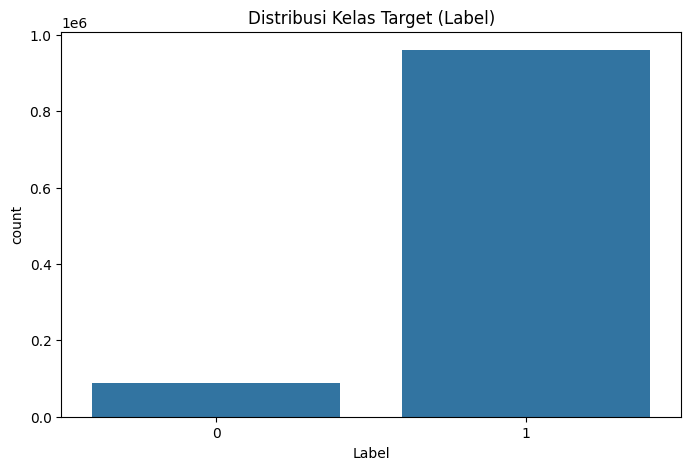

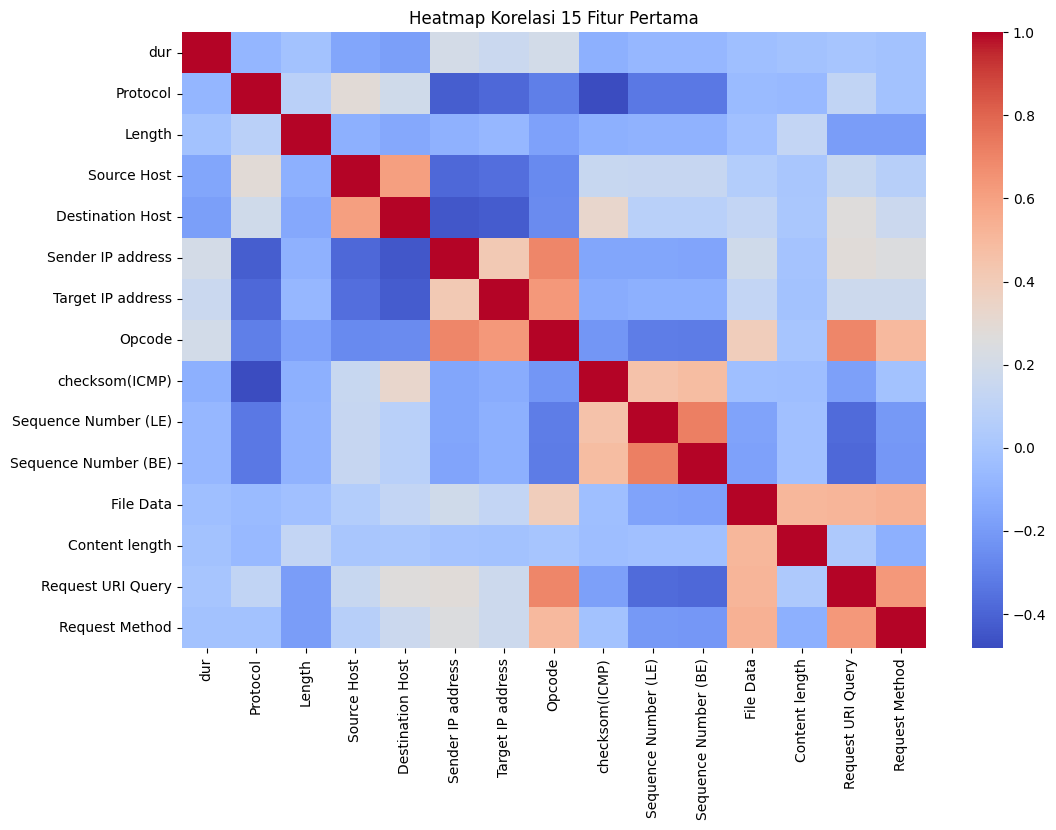

In [2]:
print("--- Cek Info Dataset ---")
display(df.info())

print("\n--- Cek Missing Values ---")
missing_values = df.isnull().sum().sum()
print(f"Total data yang bolong (Missing Values): {missing_values}")


plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Label')
plt.title("Distribusi Kelas Target (Label)")
plt.show()


kolom_contekan = ['Label', 'Attack_Category', 'Attack_sub_category']
fitur_aja = df.drop(columns=[col for col in kolom_contekan if col in df.columns])


plt.figure(figsize=(12,8))
sns.heatmap(fitur_aja.iloc[:, :15].corr(), annot=False, cmap='coolwarm')
plt.title("Heatmap Korelasi 15 Fitur Pertama")
plt.show()

ini pada dasarnya menunjukkan kondisi awal dataset yang mau di olah. Dari grafik batang di atas, kelihatan jelas kalau datanya sudah bersih dari nilai kosong, tapi sayangnya jumlah kelas targetnya sangat jomplang (imbalanced). Label "1" mendominasi banget sampai nyaris menyentuh angka satu juta, sedangkan label "0" sangat sedikit. Ini ngasih sinyal kuat kalau harus menyeimbangkan datanya dulu sebelum dilatih, biar nanti modelnya nggak bias dan asal nebak angka "1" terus-terusan.

Nah, untuk grafik warna-warni di bawahnya, itu menunjukkan seberapa erat hubungan antar kolom (fitur) di data. Semakin hangat warnanya (merah/oranye), semakin kuat hubungannya, seperti yang terlihat di kelompok alamat IP atau bagian Sequence Number. Sebaliknya, warna biru berarti hubungannya berlawanan arah, dan warna pucat berarti nggak saling ngaruh sama sekali. Informasi ini penting banget buat seleksi fitur; kalau ada dua kolom yang warnanya terlalu merah (korelasinya nyaris 1), lebih baik salah satunya dibuang saja supaya komputasi program nanti lebih ringan dan efisien.

In [3]:
from imblearn.under_sampling import RandomUnderSampler

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

kolom_contekan = ['Label', 'Attack_Category', 'Attack_sub_category']
X = df.drop(columns=[col for col in kolom_contekan if col in df.columns])
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Ukuran Data Latihan (Train):", X_train.shape)
print("Ukuran Data Ujian (Test):", X_test.shape)

Ukuran Data Latihan (Train): (838860, 85)
Ukuran Data Ujian (Test): (209715, 85)


Data dibagi menjadi 80% untuk melatih model (train) dan 20% untuk mengetes model (test). Hasil di bawahnya menunjukkan sekitar 838 ribu baris data latih dan 209 ribu baris data uji, dengan 85 kolom fitur. Penggunaan perintah stratify=y di sana sangat tepat; ini memastikan pembagian datanya adil, sehingga proporsi label "1" dan "0" yang jomplang tadi tetap sama rata antara data latih dan data uji.

In [4]:
print("Sabar wok pipelinenya lagi di rakit..")

pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', RandomUnderSampler(random_state=42)), 
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=2))
])

pipeline_wrapper = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', RandomUnderSampler(random_state=42)),
    ('feature_selection', RFE(estimator=RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=2), n_features_to_select=10)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=2))
])

pipeline_embedded = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', RandomUnderSampler(random_state=42)),
    ('feature_selection', SelectFromModel(RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=2))),
    ('model', RandomForestClassifier(random_state=42, n_jobs=2))
])

print("3 Pipeline berhasil dirakit!\n")

print("Mulai ujian Try-Out (Cross Validation)... Sabarrr......⏳")

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) 
scoring_metrics = ['accuracy', 'f1_macro']

def evaluate_pipeline(pipeline, name):
    print(f"Lagi nge-test {name}...")
    results = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring_metrics, n_jobs=2)
    return {
        'Method': name,
        'Accuracy': results['test_accuracy'].mean(),
        'F1-Score': results['test_f1_macro'].mean()
    }

res_filter = evaluate_pipeline(pipeline_filter, "Filter (SelectKBest)")
res_wrapper = evaluate_pipeline(pipeline_wrapper, "Wrapper (RFE)")
res_embedded = evaluate_pipeline(pipeline_embedded, "Embedded (SelectFromModel)")

print("\n🎉 YEEAAAY ini wok hasilnya:")
df_results = pd.DataFrame([res_filter, res_wrapper, res_embedded])
display(df_results)

Sabar wok pipelinenya lagi di rakit..
3 Pipeline berhasil dirakit!

Mulai ujian Try-Out (Cross Validation)... Sabarrr......⏳
Lagi nge-test Filter (SelectKBest)...
Lagi nge-test Wrapper (RFE)...
Lagi nge-test Embedded (SelectFromModel)...

🎉 YEEAAAY ini wok hasilnya:


,Method,Accuracy,F1-Score
0,Filter (SelectKBest),0.998696,0.995758
1,Wrapper (RFE),1.000000,1.000000
2,Embedded (SelectFromModel),1.000000,1.000000


ini bukan overfitting.
Kalau overfitting, biasanya nilai waktu diajarin itu 100%, tapi pas dites ujian (Cross Validation) nilainya anjlok jadi 60% atau 70%. Nah, angka 1.0 yang did apat ini adalah nilai ujian Try-Out (Cross Validation). Jadi modelnya memang beneran bisa nebak dengan sempurna.

Terus, kenapa nilainya bisa mulus 100% begini, di manipulasi dk, overfitting ini mah ?

Datasetnya Memang Gampang: Dataset IoT buatan akademis itu kadang polanya sangat kentara. Algoritma Random Forest itu sangat pintar, jadi dia bisa langsung membedakan mana data aman dan mana data serangan.
Kondisi Data Sudah Seimbang: Karena tadi kami pakai RandomUnderSampler, datanya jadi rapi banget. Modelnya nggak kebingungan lagi.

In [5]:
print("Mencari setelan terbaik untuk metode Filter...")

param_grid = {
    'feature_selection__k': [5, 10, 15], 
    'model__n_estimators': [20, 50]      
}

grid_search = GridSearchCV(pipeline_filter, param_grid, cv=3, scoring='f1_macro', n_jobs=2, verbose=1)
grid_search.fit(X_train, y_train)

print("\nSetelan Terbaik (Best Parameters):", grid_search.best_params_)

print("\nUjian Akhir pakai data Test (X_test)...")
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print("\n--- RAPOR AKHIR (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

joblib.dump(best_pipeline, 'pipeline_terbaik.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\n yeeeee..... 🎉 File pipeline_terbaik.pkl dan label_encoder.pkl udah berhasil dibuat.")

Mencari setelan terbaik untuk metode Filter...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Setelan Terbaik (Best Parameters): {'feature_selection__k': 15, 'model__n_estimators': 20}

Ujian Akhir pakai data Test (X_test)...

--- RAPOR AKHIR (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     17730
           1       1.00      1.00      1.00    191985

    accuracy                           1.00    209715
   macro avg       1.00      0.99      1.00    209715
weighted avg       1.00      1.00      1.00    209715


 yeeeee..... 🎉 File pipeline_terbaik.pkl dan label_encoder.pkl udah berhasil dibuat.
